<a href="https://colab.research.google.com/github/Srishti160/Oral-Cancer-Detection/blob/tempo/Tissue(Raman_Spectra).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Selecting Model and maintaing its accuracy with Oral_Dataset

In [ ]:
from sklearn.utils import class_weight
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("oral_cancer.csv")

# Extract labels, skipping the first row (assumed to be Raman shift metadata)
labels = df.loc[1:, 'labels'].astype(float).values

# Compute class weights to handle class imbalance
weights = class_weight.compute_class_weight(class_weight='balanced',
                                            classes=np.unique(labels),
                                            y=labels)

# Convert to dictionary for easy use in ML models
class_weights = dict(zip(np.unique(labels), weights))

# Display the computed class weights
for label, weight in class_weights.items():
    print(f"Class {label}: Weight = {weight:.3f}")


Class 0.0: Weight = 1.005
Class 1.0: Weight = 1.004
Class 2.0: Weight = 0.542
Class 3.0: Weight = 2.506
Class 4.0: Weight = 1.309


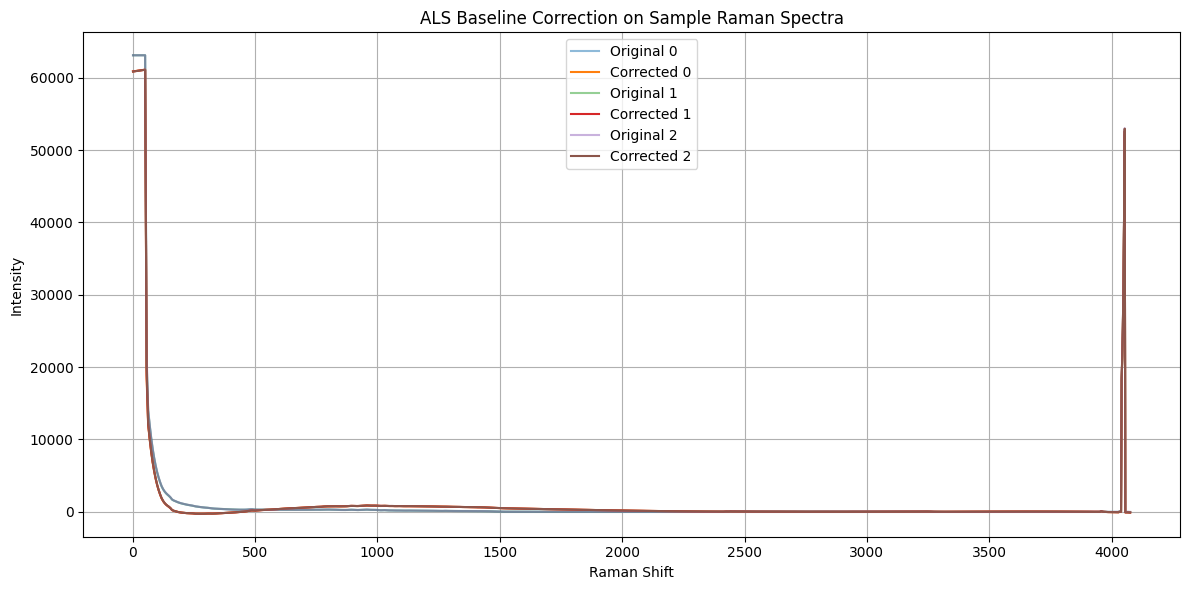

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("oral_cancer.csv")

# Extract Raman shift (x-axis values) from the first row
raman_shift = df.iloc[0, 2:].astype(float).values

# Extract spectral data from rows 1 onward (skip header row)
spectra = df.iloc[1:, 2:].astype(float).values

# Function for ALS baseline correction
def baseline_als(y, lam=1e6, p=0.01, niter=10):
    from scipy import sparse
    from scipy.sparse.linalg import spsolve
    L = len(y)
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L - 2))
    D = lam * D.dot(D.transpose())
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + D
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

# Select a small sample for ALS correction (e.g. first 3 spectra)
sample_spectra = spectra[:3]
corrected_sample_spectra = np.array([s - baseline_als(s) for s in sample_spectra])

# Plot original and corrected spectra
plt.figure(figsize=(12, 6))
for i in range(len(sample_spectra)):
    plt.plot(raman_shift, sample_spectra[i], label=f'Original {i}', alpha=0.5)
    plt.plot(raman_shift, corrected_sample_spectra[i], label=f'Corrected {i}')
plt.title("ALS Baseline Correction on Sample Raman Spectra")
plt.xlabel("Raman Shift")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


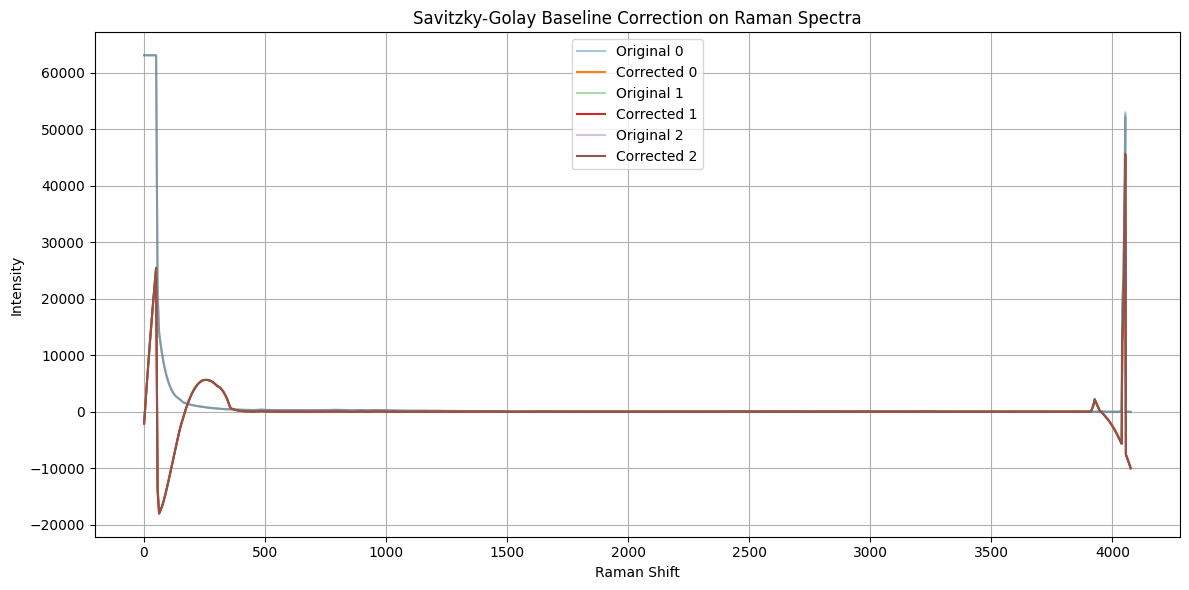

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Load dataset
df = pd.read_csv("oral_cancer.csv")

# Extract Raman shift values from the first row (metadata)
raman_shift = df.iloc[0, 2:].astype(float).values

# Extract Raman spectra from the remaining rows
spectra = df.iloc[1:, 2:].astype(float).values

# Apply Savitzky-Golay filter to estimate baseline
window_length = 101  # must be odd and less than the number of features
polyorder = 3

# Estimate and subtract the baseline
savgol_baseline = savgol_filter(spectra, window_length=window_length, polyorder=polyorder, axis=1)
corrected_spectra = spectra - savgol_baseline

# Plot original vs corrected spectra for the first 3 samples
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(raman_shift, spectra[i], label=f'Original {i}', alpha=0.4)
    plt.plot(raman_shift, corrected_spectra[i], label=f'Corrected {i}')
plt.title("Savitzky-Golay Baseline Correction on Raman Spectra")
plt.xlabel("Raman Shift")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.signal import savgol_filter
from tabulate import tabulate  # for pretty table printing

# Load dataset
df = pd.read_csv("oral_cancer.csv")

# Extract Raman shift metadata (first row), and actual spectra
raman_shift = df.iloc[0, 2:].astype(float).values
spectra = df.iloc[1:, 2:].astype(float).values
labels = df.loc[1:, 'labels'].astype(float).values

# Apply Savitzky-Golay filter for baseline correction
window_length = 101
polyorder = 3
savgol_baseline = savgol_filter(spectra, window_length=window_length, polyorder=polyorder, axis=1)
corrected_spectra = spectra - savgol_baseline

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    corrected_spectra, labels, test_size=0.30, stratify=labels, random_state=42
)

# Second split: Validation (15%) and Test (15%) from Temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Count samples per class in each subset
def class_distribution(y):
    unique, counts = np.unique(y, return_counts=True)
    return dict(zip(unique, counts))

train_dist = class_distribution(y_train)
val_dist = class_distribution(y_val)
test_dist = class_distribution(y_test)

# Combine into table format
classes = sorted(set(train_dist) | set(val_dist) | set(test_dist))
table = []
for cls in classes:
    table.append([
        cls,
        train_dist.get(cls, 0),
        val_dist.get(cls, 0),
        test_dist.get(cls, 0)
    ])

# Print table
headers = ["Class", "Train", "Validation", "Test"]
print(tabulate(table, headers=headers, tablefmt="github"))


|   Class |   Train |   Validation |   Test |
|---------|---------|--------------|--------|
|       0 |     492 |          105 |    106 |
|       1 |     493 |          105 |    106 |
|       2 |     913 |          196 |    196 |
|       3 |     197 |           43 |     42 |
|       4 |     378 |           81 |     81 |


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.signal import savgol_filter
from tabulate import tabulate

# 1. Load the dataset
df = pd.read_csv("oral_cancer.csv")

# 2. Extract data
raman_shift = df.iloc[0, 2:].astype(float).values
spectra = df.iloc[1:, 2:].astype(float).values
labels = df.loc[1:, 'labels'].astype(float).values

# 3. Baseline correction using Savitzky-Golay filter
corrected_spectra = spectra - savgol_filter(spectra, window_length=101, polyorder=3, axis=1)

# 4. Split the dataset with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    corrected_spectra, labels, test_size=0.3, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# 5. Compute class weights
class_weights_array = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights_array))

# 6. Define all models
models = {
    "SVM (RBF Kernel)": SVC(kernel="rbf", class_weight=class_weights, probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight=class_weights, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# 7. Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "accuracy": acc,
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"]
    }

# 8. Print results
table = []
for model, metrics in results.items():
    table.append([
        model,
        f"{metrics['accuracy']:.2f}",
        f"{metrics['precision_macro']:.2f}",
        f"{metrics['recall_macro']:.2f}",
        f"{metrics['f1_macro']:.2f}"
    ])

headers = ["Model", "Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"]
print(tabulate(table, headers=headers, tablefmt="grid"))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:59:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


+----------------------+------------+---------------------+------------------+--------------------+
| Model                |   Accuracy |   Precision (Macro) |   Recall (Macro) |   F1 Score (Macro) |
+======================+============+=====================+==================+====================+
| SVM (RBF Kernel)     |       0.42 |                0.4  |             0.46 |               0.4  |
+----------------------+------------+---------------------+------------------+--------------------+
| Random Forest        |       0.89 |                0.93 |             0.88 |               0.9  |
+----------------------+------------+---------------------+------------------+--------------------+
| Neural Network (MLP) |       0.63 |                0.69 |             0.64 |               0.61 |
+----------------------+------------+---------------------+------------------+--------------------+
| XGBoost              |       0.93 |                0.95 |             0.93 |               0.94 |


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:20:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:20:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:20:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

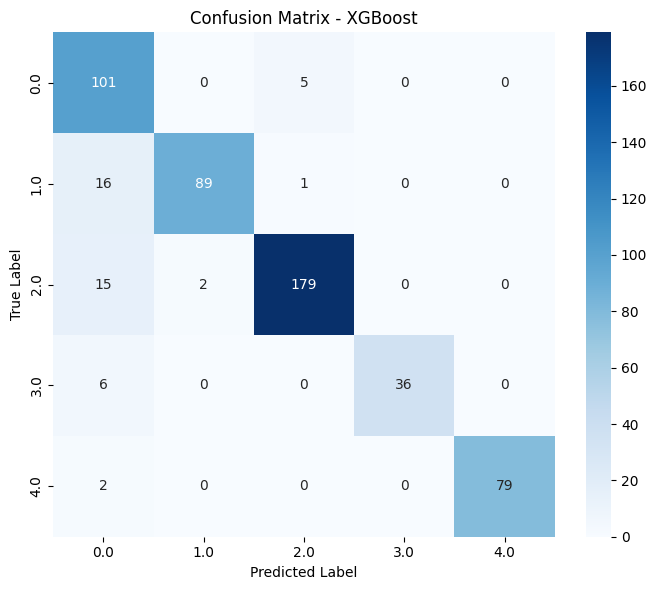

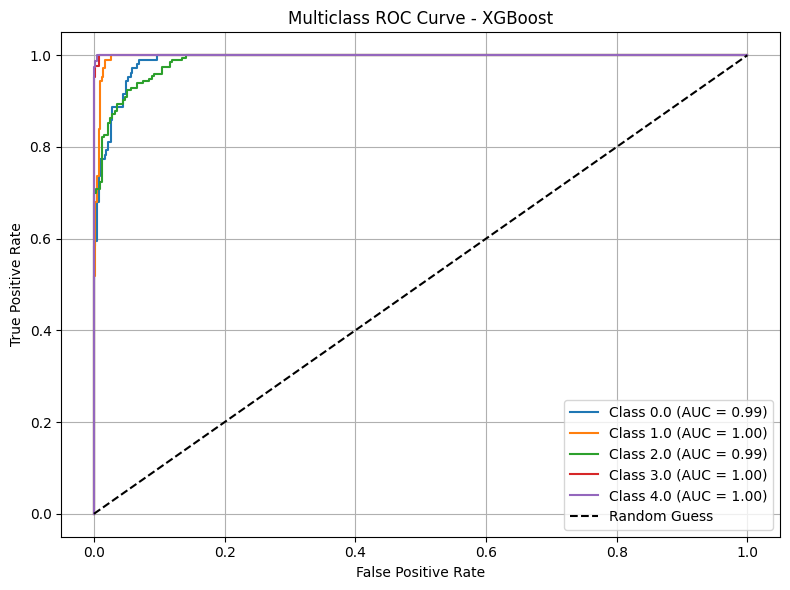

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
import numpy as np

# Get unique class labels
class_names = np.unique(y_train)

# 1. Train One-vs-Rest XGBoost model for multiclass
xgb_model = OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
xgb_model.fit(X_train, label_binarize(y_train, classes=class_names))

# 2. Predictions
y_pred = xgb_model.predict(X_test)
y_score = xgb_model.predict_proba(X_test)

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred.argmax(axis=1))  # use .argmax() because predictions are binarized
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

# 4. ROC Curve for multiclass
y_test_bin = label_binarize(y_test, classes=class_names)
n_classes = len(class_names)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"Class {class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:30:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Time: 161.12 seconds

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       563
         1.0       0.98      0.99      0.99       563
         2.0       0.99      1.00      0.99      1044
         3.0       1.00      0.97      0.98       226
         4.0       1.00      1.00      1.00       432

    accuracy                           0.99      2828
   macro avg       0.99      0.99      0.99      2828
weighted avg       0.99      0.99      0.99      2828



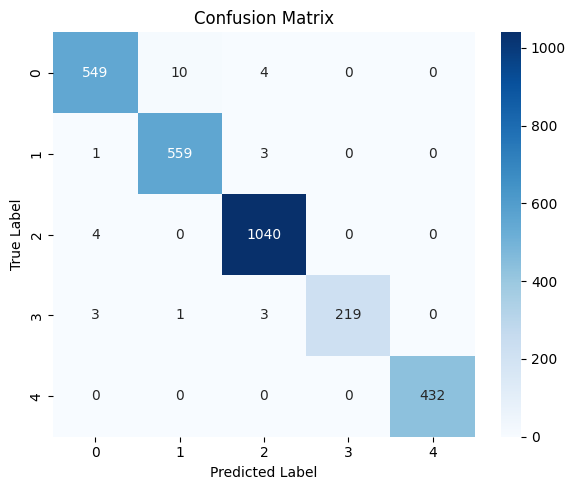

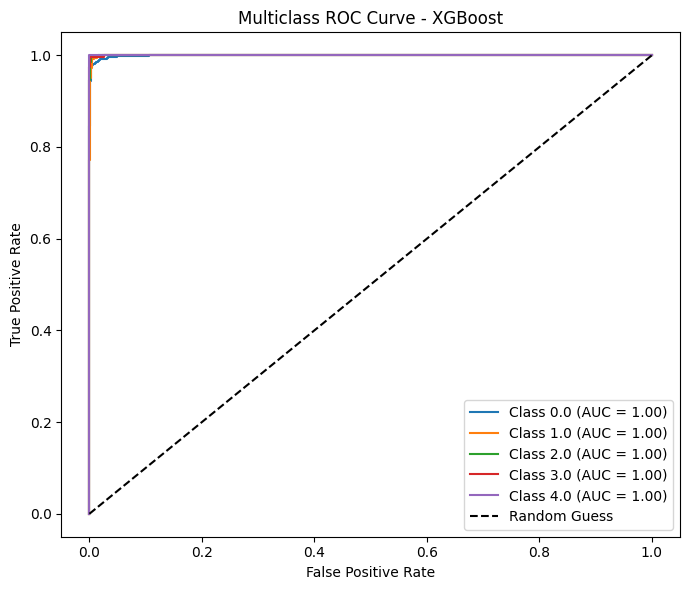

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

# === 1. Load Data ===
df = pd.read_csv("oral_cancer.csv")  # <-- Replace with your CSV file
X = df.drop(['raman_type', 'labels'], axis=1)
y = df['labels']

# === 2. Data Augmentation ===
def augment_data(X, y, noise_level=0.02, offset=5, baseline_slope=0.002, copies=3):
    augmented_X = []
    augmented_y = []

    for _ in range(copies):
        noise = np.random.normal(0, noise_level, X.shape)
        vertical_offset = np.random.uniform(-offset, offset, X.shape)
        baseline = np.linspace(0, baseline_slope * X.shape[1], X.shape[1])
        baseline = np.tile(baseline, (X.shape[0], 1))

        X_aug = X + noise + vertical_offset + baseline
        augmented_X.append(X_aug)
        augmented_y.append(y.copy())

    X_aug = pd.concat([X] + augmented_X, axis=0)
    y_aug = pd.concat([y] + augmented_y, axis=0)
    return X_aug, y_aug

X_aug, y_aug = augment_data(X, y)

# Drop rows with NaN (if any)
X_aug = X_aug.reset_index(drop=True)
y_aug = y_aug.reset_index(drop=True)
mask = y_aug.notna()
X_aug = X_aug[mask]
y_aug = y_aug[mask]

# === 3. Train-test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)

# === 4. Train XGBoost Model ===
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
start = time.time()
model.fit(X_train, y_train)
end = time.time()
print(f"Training Time: {end - start:.2f} seconds")

# === 5. Evaluation ===
y_pred = model.predict(X_test)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# === 6. ROC Curve ===
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model.predict_proba(X_test)

plt.figure(figsize=(7, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("Multiclass ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Identification of Peak Intensities and Peak area ratios etc.

# Data Augmnetation, feature Attraction and Training Model

In [ ]:
import pandas as pd

# Load the extracted features CSV
df_features = pd.read_csv("oral_cancer.csv")

# Auto-detect label column
label_col = "label" if "label" in df_features.columns else "labels"

# Count only the feature columns
num_features = df_features.drop(columns=[label_col]).shape[1]

# Define breakdown manually (adjust if needed)
feature_breakdown = {
    "Peak Intensities": 3,
    "Peak Area Ratio": 1,
    "PCA Scores": 3,
    "Wavelet Feature (Haar)": 1,
    "1st Derivative Mean": 1,
    "2nd Derivative Mean": 1,
    "Spectral Entropy": 1,
    "Skewness": 1
}

# Display results
print(f"✅ Total Features Extracted per Sample: {num_features}\n")
print("📊 Feature Breakdown:")
for k, v in feature_breakdown.items():
    print(f"- {k}: {v}")


✅ Total Features Extracted per Sample: 1039

📊 Feature Breakdown:
- Peak Intensities: 3
- Peak Area Ratio: 1
- PCA Scores: 3
- Wavelet Feature (Haar): 1
- 1st Derivative Mean: 1
- 2nd Derivative Mean: 1
- Spectral Entropy: 1
- Skewness: 1


In [ ]:
# 📌 Step 1: Load Raw Data

import pandas as pd

raw_df = pd.read_csv("oral_cancer.csv")

# Inspect the dataset
print("Dataset shape:", raw_df.shape)
print("Columns:", raw_df.columns[:10].tolist(), "...")
print("Label distribution:\n", raw_df['labels'].value_counts())


Dataset shape: (3535, 1040)
Columns: ['raman_type', 'labels', 'Var0', 'Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7'] ...
Label distribution:
 labels
2.0    1305
1.0     704
0.0     703
4.0     540
3.0     282
Name: count, dtype: int64


In [ ]:
import numpy as np

def augment_spectra(df, intensity_cols):
    augmented = []

    for _, row in df.iterrows():
        spectrum = row[intensity_cols].values.astype(float)
        label = row["labels"]

        # Original
        augmented.append(np.append(spectrum, label))

        # Augmentation 1: Add Gaussian noise
        noise = np.random.normal(0, 0.01, size=spectrum.shape)
        augmented.append(np.append(spectrum + noise, label))

        # Augmentation 2: Add baseline offset
        offset = np.random.uniform(-0.05, 0.05)
        augmented.append(np.append(spectrum + offset, label))

        # Augmentation 3: Both noise + baseline
        combined = spectrum + noise + offset
        augmented.append(np.append(combined, label))

    columns = intensity_cols + ["labels"]
    df_aug = pd.DataFrame(augmented, columns=columns)
    return df_aug

# Extract intensity column names
intensity_cols = [col for col in raw_df.columns if col.startswith("Var")]

# Apply augmentation
df_augmented = augment_spectra(raw_df, intensity_cols)

print("Original samples:", len(raw_df))
print("After augmentation:", len(df_augmented))
df_augmented.head()


Original samples: 3535
After augmentation: 14140


,Var0,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,...,Var1029,Var1030,Var1031,Var1032,Var1033,Var1034,Var1035,Var1036,Var1037,labels
0,1.725000,7.944000,14.155000,20.360000,26.558000,32.749000,38.933000,45.110000,51.280000,57.444000,...,4055.642000,4058.121000,4060.598000,4063.073000,4065.547000,4068.018000,4070.488000,4072.956000,4075.423000,NaN
1,1.727989,7.938154,14.176323,20.353311,26.551911,32.745723,38.934856,45.125343,51.281115,57.435065,...,4055.622373,4058.109274,4060.595025,4063.069576,4065.548325,4068.006232,4070.491610,4072.970087,4075.419339,NaN
2,1.742312,7.961312,14.172312,20.377312,26.575312,32.766312,38.950312,45.127312,51.297312,57.461312,...,4055.659312,4058.138312,4060.615312,4063.090312,4065.564312,4068.035312,4070.505312,4072.973312,4075.440312,NaN
3,1.745301,7.955466,14.193635,20.370623,26.569223,32.763036,38.952168,45.142656,51.298427,57.452378,...,4055.639685,4058.126586,4060.612337,4063.086889,4065.565638,4068.023544,4070.508922,4072.987399,4075.436652,NaN
4,63103.476000,63104.476000,63104.476000,63102.476000,63102.476000,63104.476000,63104.476000,63103.476000,63103.476000,20308.076000,...,-18.724000,-16.324000,-15.524000,-15.924000,-15.724000,-15.124000,-24.724000,-23.524000,-26.124000,0.0


In [ ]:
import numpy as np
import pandas as pd

# Load your original data
raw_df = pd.read_csv("oral_cancer.csv")  # Already done

# Extract only the spectra and labels
spectra = raw_df.filter(regex="^Var").values
labels = raw_df["labels"].values

aug_spectra = [spectra]
aug_labels = [labels]

# Augmentation: Add Gaussian noise, vertical shifts, baseline drift etc.
for _ in range(3):  # generate 3 augmented copies
    noise = np.random.normal(0, 0.01, spectra.shape)
    vertical_offset = np.random.normal(0, 0.1, (spectra.shape[0], 1))
    baseline = np.linspace(0, 1, spectra.shape[1]) * np.random.normal(0, 0.05)

    augmented = spectra + noise + vertical_offset + baseline
    aug_spectra.append(augmented)
    aug_labels.append(labels)  # 🔴 THIS is the crucial part you missed

# Stack all augmented data
X_augmented = np.vstack(aug_spectra)
y_augmented = np.concatenate(aug_labels)

# Convert to DataFrame and assign column names
df_augmented = pd.DataFrame(X_augmented, columns=[f"Var{i}" for i in range(X_augmented.shape[1])])
df_augmented["labels"] = y_augmented.astype(int)

# Show shape and head
print(f"Original samples: {len(raw_df)}")
print(f"After augmentation: {len(df_augmented)}")
display(df_augmented.head())


Original samples: 3535
After augmentation: 14140


,Var0,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,...,Var1029,Var1030,Var1031,Var1032,Var1033,Var1034,Var1035,Var1036,Var1037,labels
0,1.725,7.944,14.155,20.360,26.558,32.749,38.933,45.110,51.280,57.444,...,4055.642,4058.121,4060.598,4063.073,4065.547,4068.018,4070.488,4072.956,4075.423,-9223372036854775808
1,63103.476,63104.476,63104.476,63102.476,63102.476,63104.476,63104.476,63103.476,63103.476,20308.076,...,-18.724,-16.324,-15.524,-15.924,-15.724,-15.124,-24.724,-23.524,-26.124,0
2,63103.648,63104.648,63104.648,63102.648,63102.648,63104.648,63104.648,63103.648,63103.648,20841.248,...,-30.352,-25.152,-27.352,-26.152,-24.752,-28.152,-42.152,-40.552,-42.752,0
3,63103.750,63104.750,63104.750,63102.750,63102.750,63104.750,63104.750,63103.750,63103.750,21749.150,...,-18.050,-14.850,-16.450,-15.050,-14.450,-16.450,-25.650,-23.650,-23.850,0
4,63102.350,63103.350,63103.350,63101.350,63101.350,63103.350,63103.350,63102.350,63102.350,24393.350,...,-30.050,-25.650,-27.650,-27.850,-25.450,-27.050,-45.450,-40.250,-43.650,0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import entropy, skew

# --------------------------
# Feature Extraction Function
# --------------------------
def extract_features_from_spectrum(spectrum, wavenumbers):
    features = {}

    # 1. Mean and Variance
    features['mean_intensity'] = np.mean(spectrum)
    features['var_intensity'] = np.var(spectrum)

    # 2. Spectral entropy and skewness
    spectrum_positive = spectrum - np.min(spectrum) + 1e-6
    prob_dist = spectrum_positive / np.sum(spectrum_positive)
    features['entropy'] = entropy(prob_dist)
    features['skewness'] = skew(spectrum)

    # 3. Peak intensities at diagnostic bands
    peak_positions = {
        "peak_1003": 1003,
        "peak_1265": 1265,
        "peak_1335": 1335,
        "peak_1445": 1445,
        "peak_1650": 1650,
    }
    for name, wn in peak_positions.items():
        idx = np.argmin(np.abs(wavenumbers - wn))
        features[name] = spectrum[idx]

    # 4. Ratios
    features["ratio_1003_1650"] = features["peak_1003"] / (features["peak_1650"] + 1e-6)
    features["ratio_1445_1265"] = features["peak_1445"] / (features["peak_1265"] + 1e-6)

    return features

# --------------------------
# Prepare Input Data
# --------------------------

spectral_cols = [col for col in df_augmented.columns if col.startswith("Var")]
X_raw = df_augmented[spectral_cols].values
y = df_augmented["labels"].values

# Simulated wavenumbers: 400 to 1800 cm⁻¹
wavenumbers = np.linspace(400, 1800, X_raw.shape[1])

# --------------------------
# Extract Features
# --------------------------

feature_list = []
for spectrum in X_raw:
    feats = extract_features_from_spectrum(spectrum, wavenumbers)
    feature_list.append(feats)

features_df = pd.DataFrame(feature_list)

# --------------------------
# Add PCA Features (10)
# --------------------------

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_raw)
for i in range(10):
    features_df[f'PCA_{i+1}'] = X_pca[:, i]

# Add labels
features_df["label"] = y

# Save to CSV
features_df.to_csv("X_features.csv", index=False)

# Show summary
print("✅ Feature extraction complete.")
print(f"Total Features Extracted per Sample: {features_df.shape[1] - 1}")
features_df.head()


✅ Feature extraction complete.
Total Features Extracted per Sample: 21


,mean_intensity,var_intensity,entropy,skewness,peak_1003,peak_1265,peak_1335,peak_1445,peak_1650,ratio_1003_1650,...,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,label
0,2350.070933,1.348508e+06,6.797815,-0.322368,2226.231,2935.303,3106.247,3358.449,3790.222,0.587362,...,-92855.050719,-94729.736810,67488.628562,21968.584318,-28319.395681,-81400.632621,-46769.291733,-15328.634702,4816.711534,-9223372036854775808
1,911.787753,4.135441e+07,3.689967,8.803326,-5.124,30.676,29.076,-14.524,-14.724,0.348003,...,9457.763616,14407.232057,2692.571735,11929.497556,-12261.695632,1227.609954,4219.044196,-1459.785991,1225.603264,0
2,912.694821,4.149848e+07,3.777180,8.784738,-8.152,29.648,29.048,-21.752,-25.552,0.319036,...,9864.120912,14332.080964,2869.220356,11775.934023,-12010.788141,1224.148225,4039.144717,-1410.161608,1165.866722,0
3,919.552505,4.163388e+07,3.698774,8.764693,-5.650,30.150,29.150,-12.850,-15.250,0.370492,...,10355.912527,14198.481980,3188.417998,11487.879037,-11567.898516,1224.413189,3748.161585,-1383.715191,1050.869039,0
4,924.071195,4.201462e+07,3.796715,8.711758,-8.650,30.950,29.150,-22.050,-26.050,0.332054,...,11759.824740,13811.215840,4121.924416,10685.386553,-10255.408756,1267.634022,2872.253072,-1334.485144,670.708833,0


In [ ]:
print(df_features.columns.tolist())

['raman_type', 'labels', 'Var0', 'Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10', 'Var11', 'Var12', 'Var13', 'Var14', 'Var15', 'Var16', 'Var17', 'Var18', 'Var19', 'Var20', 'Var21', 'Var22', 'Var23', 'Var24', 'Var25', 'Var26', 'Var27', 'Var28', 'Var29', 'Var30', 'Var31', 'Var32', 'Var33', 'Var34', 'Var35', 'Var36', 'Var37', 'Var38', 'Var39', 'Var40', 'Var41', 'Var42', 'Var43', 'Var44', 'Var45', 'Var46', 'Var47', 'Var48', 'Var49', 'Var50', 'Var51', 'Var52', 'Var53', 'Var54', 'Var55', 'Var56', 'Var57', 'Var58', 'Var59', 'Var60', 'Var61', 'Var62', 'Var63', 'Var64', 'Var65', 'Var66', 'Var67', 'Var68', 'Var69', 'Var70', 'Var71', 'Var72', 'Var73', 'Var74', 'Var75', 'Var76', 'Var77', 'Var78', 'Var79', 'Var80', 'Var81', 'Var82', 'Var83', 'Var84', 'Var85', 'Var86', 'Var87', 'Var88', 'Var89', 'Var90', 'Var91', 'Var92', 'Var93', 'Var94', 'Var95', 'Var96', 'Var97', 'Var98', 'Var99', 'Var100', 'Var101', 'Var102', 'Var103', 'Var104', 'Var105', 'Var106', 'Var107', 'Var1

✅ Shapes:
X_train: (2827, 1038)
X_test:  (707, 1038)
y_train: (2827,)
y_test:  (707,)

🧾 Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       0.97      0.89      0.93       141
         1.0       0.96      0.98      0.97       141
         2.0       0.95      0.98      0.97       261
         3.0       0.96      0.95      0.95        56
         4.0       0.99      1.00      1.00       108

    accuracy                           0.96       707
   macro avg       0.97      0.96      0.96       707
weighted avg       0.96      0.96      0.96       707



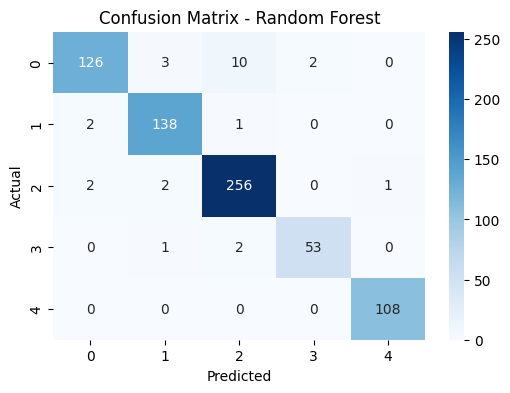


🧾 Classification Report (XGBoost):
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       141
         1.0       0.97      0.99      0.98       141
         2.0       0.98      0.98      0.98       261
         3.0       1.00      0.98      0.99        56
         4.0       1.00      1.00      1.00       108

    accuracy                           0.98       707
   macro avg       0.98      0.98      0.98       707
weighted avg       0.98      0.98      0.98       707



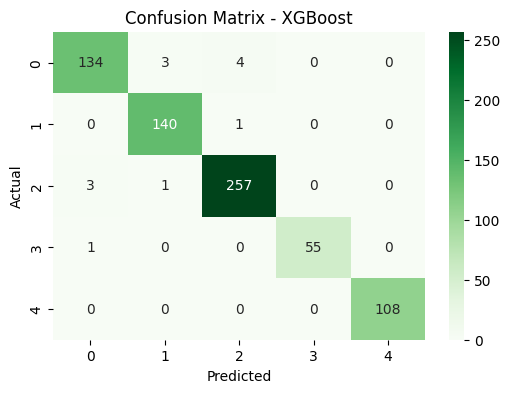

In [ ]:
# -----------------------------
# 📦 MODEL TRAINING & EVALUATION
# -----------------------------

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Drop 'raman_type' if it exists — we only want numerical features
if "raman_type" in df_features.columns:
    df_features = df_features.drop(columns=["raman_type"])

# ✅ Remove any rows with missing labels
df_features = df_features.dropna(subset=["labels"])

# ✅ Extract features and labels
X = df_features.drop(columns=["labels"])
y = df_features["labels"]

# ✅ Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("✅ Shapes:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

# -----------------------------
# 🐲 Train Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n🧾 Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 🚀 Train XGBoost
# -----------------------------
xgb = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\n🧾 Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Crop Data(500-2000)

In [ ]:
print(df.columns.tolist())

['raman_type', 'labels', 'Var0', 'Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10', 'Var11', 'Var12', 'Var13', 'Var14', 'Var15', 'Var16', 'Var17', 'Var18', 'Var19', 'Var20', 'Var21', 'Var22', 'Var23', 'Var24', 'Var25', 'Var26', 'Var27', 'Var28', 'Var29', 'Var30', 'Var31', 'Var32', 'Var33', 'Var34', 'Var35', 'Var36', 'Var37', 'Var38', 'Var39', 'Var40', 'Var41', 'Var42', 'Var43', 'Var44', 'Var45', 'Var46', 'Var47', 'Var48', 'Var49', 'Var50', 'Var51', 'Var52', 'Var53', 'Var54', 'Var55', 'Var56', 'Var57', 'Var58', 'Var59', 'Var60', 'Var61', 'Var62', 'Var63', 'Var64', 'Var65', 'Var66', 'Var67', 'Var68', 'Var69', 'Var70', 'Var71', 'Var72', 'Var73', 'Var74', 'Var75', 'Var76', 'Var77', 'Var78', 'Var79', 'Var80', 'Var81', 'Var82', 'Var83', 'Var84', 'Var85', 'Var86', 'Var87', 'Var88', 'Var89', 'Var90', 'Var91', 'Var92', 'Var93', 'Var94', 'Var95', 'Var96', 'Var97', 'Var98', 'Var99', 'Var100', 'Var101', 'Var102', 'Var103', 'Var104', 'Var105', 'Var106', 'Var107', 'Var1

In [ ]:
import numpy as np
import pandas as pd

# Load the dataset
df = pd.read_csv('oral_cancer.csv')

# Crop to 500–2000 cm⁻¹ range
wavenumbers = np.linspace(0, 3000, 1038)  # adjust if needed
crop_mask = (wavenumbers >= 500) & (wavenumbers <= 2000)
crop_indices = np.where(crop_mask)[0]
var_cols = [f'Var{i}' for i in crop_indices]

# Use correct label column: 'labels'
df_cropped = df[var_cols + ['labels']]

# Proceed with this DataFrame
df = df_cropped.copy()

print(f"Selected {len(var_cols)} spectral features between 500–2000 cm⁻¹.")


Selected 519 spectral features between 500–2000 cm⁻¹.


# Applying SG-Filter + Normalize

Number of spectra with NaNs: 1


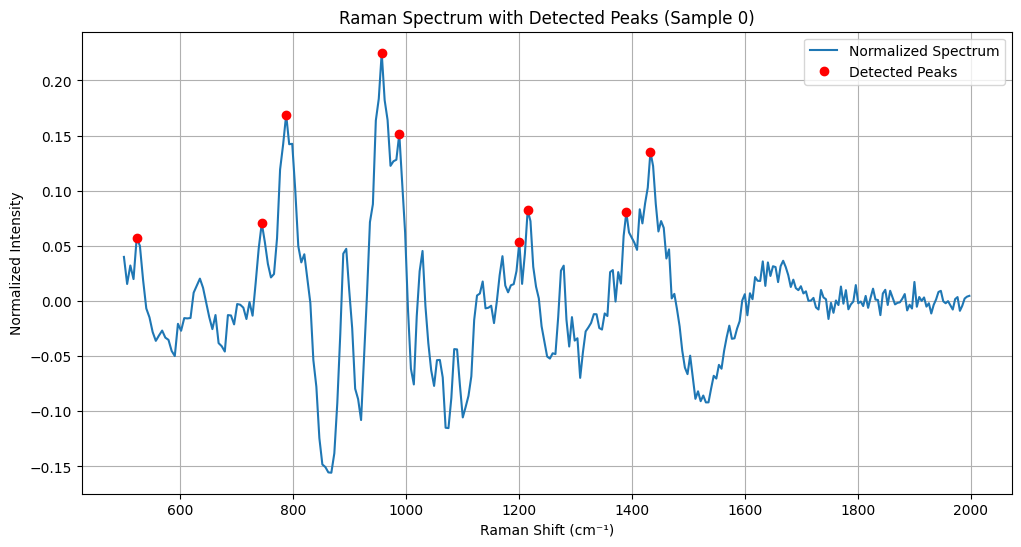

Peak at 523.63 cm⁻¹ with intensity 0.0575
Peak at 745.03 cm⁻¹ with intensity 0.0706
Peak at 788.20 cm⁻¹ with intensity 0.1690
Peak at 957.36 cm⁻¹ with intensity 0.2251
Peak at 988.46 cm⁻¹ with intensity 0.1515
Peak at 1200.95 cm⁻¹ with intensity 0.0532
Peak at 1215.79 cm⁻¹ with intensity 0.0825
Peak at 1390.41 cm⁻¹ with intensity 0.0804
Peak at 1433.11 cm⁻¹ with intensity 0.1353


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from sklearn.preprocessing import normalize

# --- Step 0: Load dataset ---
df = pd.read_csv("oral_cancer.csv")  # Change path if running in Colab

# --- Step 1: Extract Raman shift and labels ---
raman_shift = df.iloc[0, 2:].astype(float).values
spectra = df.iloc[1:, 2:].astype(float).values
labels = df.loc[1:, 'labels'].astype(float).values

# --- Step 2: Crop between 500–2000 cm⁻¹ ---
mask = (raman_shift >= 500) & (raman_shift <= 2000)
cropped_shift = raman_shift[mask]
cropped_spectra = spectra[:, mask]

# --- Step 3: Apply Savitzky-Golay filter (baseline correction) safely ---
window_length = 101
polyorder = 3
n_points = cropped_spectra.shape[1]
if window_length >= n_points:
    window_length = n_points - 1 if n_points % 2 == 0 else n_points

# Apply Savitzky-Golay filter
savgol_baseline = savgol_filter(cropped_spectra, window_length=window_length,
                                polyorder=polyorder, axis=1)
corrected_spectra = cropped_spectra - savgol_baseline

# --- Step 4: Handle NaNs from filtering ---
nan_rows = np.isnan(corrected_spectra).any(axis=1)
print(f"Number of spectra with NaNs: {nan_rows.sum()}")

# Drop NaN rows
corrected_spectra_clean = corrected_spectra[~nan_rows]
labels_clean = labels[~nan_rows]

# --- Step 5: L2 Normalize ---
normalized_spectra = normalize(corrected_spectra_clean, norm='l2', axis=1)

# --- Step 6: Create a processed DataFrame ---
df_processed = pd.DataFrame(normalized_spectra, columns=[f"{x:.2f}" for x in cropped_shift])
df_processed['labels'] = labels_clean

# --- Step 7: Peak Detection on one sample (e.g., first valid sample) ---
sample_idx = 0
spectrum = normalized_spectra[sample_idx]

# Detect peaks
peaks, properties = find_peaks(spectrum, height=0.05, prominence=0.02)

# --- Step 8: Plot spectrum with peaks ---
plt.figure(figsize=(12, 6))
plt.plot(cropped_shift, spectrum, label="Normalized Spectrum")
plt.plot(cropped_shift[peaks], spectrum[peaks], "ro", label="Detected Peaks")
plt.title(f"Raman Spectrum with Detected Peaks (Sample {sample_idx})")
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Normalized Intensity")
plt.grid(True)
plt.legend()
plt.show()

# --- Step 9: Print detected peak positions and intensities ---
for shift, intensity in zip(cropped_shift[peaks], spectrum[peaks]):
    print(f"Peak at {shift:.2f} cm⁻¹ with intensity {intensity:.4f}")


# Accuracy of Model

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ==================== 1. Load Dataset ====================
df = pd.read_csv("oral_cancer.csv")

# First row is Raman shifts → remove it
raman_shift = df.iloc[0, 2:].astype(float).values
df = df.iloc[1:].reset_index(drop=True)  # keep only spectra rows

# Extract labels
labels = df["labels"].astype(float)
labels = labels.fillna(-1)  # temporary fill
labels = labels.astype(int).values

# Check labels
print("Unique labels in y:", np.unique(labels, return_counts=True))

# Extract spectra (ignore first 2 columns)
spectra = df.iloc[:, 2:].astype(float).values

# ==================== 2. Crop 500–2000 cm⁻¹ ====================
mask = (raman_shift >= 500) & (raman_shift <= 2000)
cropped_shift = raman_shift[mask]
cropped_spectra = spectra[:, mask]

# Clean any NaN or Inf
cropped_spectra = np.nan_to_num(cropped_spectra, nan=0.0, posinf=0.0, neginf=0.0)

# ==================== 3. Savitzky-Golay Normalization ====================
window_length = 11  # small due to few points
polyorder = 3
baseline = savgol_filter(cropped_spectra, window_length=window_length, polyorder=polyorder, axis=1)
normalized_spectra = cropped_spectra - baseline
normalized_spectra = np.nan_to_num(normalized_spectra, nan=0.0, posinf=0.0, neginf=0.0)
normalized_spectra = normalize(normalized_spectra, norm='l2', axis=1)

print("Normalized spectra shape:", normalized_spectra.shape)

# ==================== 4. Compute Derivatives ====================
first_derivative = savgol_filter(normalized_spectra, window_length=11, polyorder=3, deriv=1, axis=1)
second_derivative = savgol_filter(normalized_spectra, window_length=11, polyorder=3, deriv=2, axis=1)

# Combine raw + derivatives
spectra_features = np.hstack([normalized_spectra, first_derivative, second_derivative])
print("Spectra feature shape:", spectra_features.shape)

# ==================== 5. PCA Compression ====================
scaler = StandardScaler()
scaled_spectra = scaler.fit_transform(spectra_features)

pca = PCA(n_components=min(50, scaled_spectra.shape[1]), random_state=42)
spectra_pca = pca.fit_transform(scaled_spectra)
print("PCA compressed feature shape:", spectra_pca.shape)

# ==================== 6. Peak + Statistical Features ====================
top_n_peaks = 20  # use 20 peaks for stability

def extract_peak_features(spectra, shifts, labels, top_n=10):
    feature_list, feature_labels = [], []

    for idx, spectrum in enumerate(spectra):
        peaks, props = find_peaks(spectrum, height=0.05, prominence=0.02)
        sorted_peaks = peaks[np.argsort(props['peak_heights'])[::-1]]

        top_peaks = sorted_peaks[:top_n]
        peak_positions = shifts[top_peaks]
        peak_intensities = spectrum[top_peaks]

        features = []
        for i in range(top_n):
            if i < len(top_peaks):
                features.append(peak_positions[i])
                features.append(peak_intensities[i])
            else:
                features.extend([0, 0])  # padding

        # Add mean, std, and AUC
        features.append(np.mean(spectrum))
        features.append(np.std(spectrum))
        features.append(np.trapezoid(spectrum, shifts))

        feature_list.append(features)
        feature_labels.append(labels[idx])

    columns = []
    for i in range(1, top_n+1):
        columns.extend([f"Peak_{i}_Pos", f"Peak_{i}_Int"])
    columns += ["Mean_Intensity", "Std_Intensity", "AUC"]

    df_features = pd.DataFrame(feature_list, columns=columns)
    df_features["labels"] = feature_labels
    return df_features

df_features = extract_peak_features(normalized_spectra, cropped_shift, labels, top_n=top_n_peaks)
df_features = df_features[df_features["labels"] >= 0].reset_index(drop=True)

X_peaks = df_features.drop("labels", axis=1).values
y = df_features["labels"].astype(int).values

# Combine PCA + Peak Features
X_combined = np.hstack([spectra_pca, X_peaks])
print("Final feature matrix shape:", X_combined.shape)
print("Unique labels in y after cleaning:", np.unique(y, return_counts=True))

# ==================== 7. Train-Test Split & SMOTE ====================
X_train, X_temp, y_train, y_temp = train_test_split(X_combined, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
print("After SMOTE:", X_train_res.shape, "Class distribution:", np.bincount(y_train_res.astype(int)))

# ==================== 8. XGBoost Training ====================
xgb_model = XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=1.0,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

# ==================== 9. Evaluate ====================
xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))


Unique labels in y: (array([0]), array([555]))
Normalized spectra shape: (555, 308)
Spectra feature shape: (555, 924)
PCA compressed feature shape: (555, 50)
Final feature matrix shape: (555, 93)
Unique labels in y after cleaning: (array([0]), array([555]))


ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

In [ ]:
import pandas as pd

df_check = pd.read_csv("oral_cancer.csv")
print(df_check.head(10))
print("\nColumn names:", df_check.columns.tolist())
print("\nUnique values in 'labels' column:", df_check['labels'].unique())


    raman_type  labels       Var0       Var1       Var2       Var3       Var4  \
0  raman_shift     NaN      1.725      7.944     14.155     20.360     26.558   
1       Health     0.0  63103.476  63104.476  63104.476  63102.476  63102.476   
2       Health     0.0  63103.648  63104.648  63104.648  63102.648  63102.648   
3       Health     0.0  63103.750  63104.750  63104.750  63102.750  63102.750   
4       Health     0.0  63102.350  63103.350  63103.350  63101.350  63101.350   
5       Health     0.0  63102.876  63103.876  63103.876  63101.876  63101.876   
6       Health     0.0  63103.476  63104.476  63104.476  63102.476  63102.476   
7       Health     0.0  63073.950  63074.950  63074.950  63072.950  63072.950   
8       Health     0.0  63072.098  63073.098  63073.098  63071.098  63071.098   
9       Health     0.0  63073.100  63074.100  63074.100  63072.100  63072.100   

        Var5       Var6       Var7  ...    Var1028   Var1029   Var1030  \
0     32.749     38.933     45.110